# 06. Evaluación final sobre el conjunto de prueba

**La única pasada sobre el test.** El 20% de prueba se apartó en la Fase 2 y nadie lo
tocó hasta este punto. Antes de correr esta evaluación verificamos que ninguna parte del
código leía `test.parquet` fuera de `src/evaluacion_final.py`, que la división de los
datos no se había regenerado (el script se niega a hacerlo) y que `Destination Port` es
el único identificador entre las 48 features. Más adelante se agregó
`src/preparar_demo.py`, que también lee el test, pero solo para sacar las muestras de
los archivos de demostración del tablero, sin calcular ninguna métrica.

**Reglas de esta fase:**
- El punto de operación de Bot (se da la alarma solo si P(Bot) ≥ 0,999, y si no se
  asigna la segunda clase más probable) se fijó antes, con probabilidades out-of-fold
  del conjunto de entrenamiento.
- El mejor modelo (árboles + pesos de clase) se reentrenó con todo el conjunto de
  entrenamiento, en dos variantes: con puerto y sin identificadores.
- **Una vez visto el test, no se reajusta nada.** Se reporta lo que salió.

> **Nota:** el cómputo está en `python -m src.evaluacion_final` (con checkpoint, se
> niega a recalcular). Este notebook lee los CSVs de `reports/resultados_final/`.

In [1]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RUTA_FIGURAS
from src.evaluacion_final import RUTA_EXPORT
from src.resultados import RUTA_EXPORT as RUTA_FASE3

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110

macro = pd.read_csv(RUTA_EXPORT / "final_multiclase_macro.csv")
por_clase = pd.read_csv(RUTA_EXPORT / "final_multiclase_por_clase.csv")
binario = pd.read_csv(RUTA_EXPORT / "final_binario_metricas.csv")
raras = pd.read_csv(RUTA_EXPORT / "final_binario_raras.csv")
if_recall = pd.read_csv(RUTA_EXPORT / "final_iforest_recall.csv")
if_fp = pd.read_csv(RUTA_EXPORT / "final_iforest_fp_dia.csv")
print("Resultados de la evaluación final cargados")

Resultados de la evaluación final cargados


## 1. ¿Coinciden el test y la validación cruzada? (prueba de sobreajuste)

In [2]:
# Validación cruzada (train, Fases 3 y 4) contra el test, con la misma regla de decisión (argmax)
cv_macro = pd.read_csv(RUTA_FASE3 / "fase3_macro_f1.csv")
cv_con = cv_macro.query("modelo == 'Árboles (HistGB)' and tecnica == 'Pesos de clase'")
cv_sin = pd.read_csv(RUTA_EXPORT.parent / "resultados_fase4" / "q1_puerto_macro_f1.csv")
cv_sin = cv_sin.query("variante == 'sin_puerto'")["macro_f1"]

comparacion = pd.DataFrame(
    {
        "CV en train (media ± desv)": [
            f"{cv_con['macro_f1_media'].iloc[0]:.3f} ± {cv_con['macro_f1_desv'].iloc[0]:.3f}",
            f"{cv_sin.mean():.3f} ± {cv_sin.std():.3f}",
        ],
        "Test (única pasada, argmax)": [
            f"{macro.query('variante == \'con_puerto\' and regla == \'argmax\'')['macro_f1'].iloc[0]:.3f}",
            f"{macro.query('variante == \'sin_identificadores\' and regla == \'argmax\'')['macro_f1'].iloc[0]:.3f}",
        ],
    },
    index=["Con puerto", "Sin identificadores"],
)
comparacion

,CV en train (media ± desv),"Test (única pasada, argmax)"
Con puerto,0.970 ± 0.002,0.967
Sin identificadores,0.950 ± 0.004,0.942


**Las cifras del test coinciden con las de la validación cruzada** (0,967 frente a
0,970 ± 0,002 con puerto, y 0,942 frente a 0,950 ± 0,004 sin identificadores, ambas a
~2 desviaciones). Esto es lo que se espera de un protocolo sin fuga de información:
**no hubo sobreajuste**, y la validación cruzada sobre el entrenamiento fue una buena
estimación de lo que el modelo haría con datos nuevos.

## 2. Resultado final con la regla de operación completa

In [3]:
tabla_macro = macro.copy()
tabla_macro.columns = ["variante", "regla", "macro-F1", "macro-F1 solo ataques"]
tabla_macro.round(3)

,variante,regla,macro-F1,macro-F1 solo ataques
0,con_puerto,argmax,0.967,0.964
1,con_puerto,umbral_bot,0.975,0.972
2,sin_identificadores,argmax,0.942,0.937
3,sin_identificadores,umbral_bot,0.888,0.877


In [4]:
bot = por_clase.query("clase == 'Bot'")[["variante", "regla", "recall", "precision", "ap", "soporte"]]
print("El umbral de Bot (fijado en train), evaluado en test:")
bot.round(3)

El umbral de Bot (fijado en train), evaluado en test:


,variante,regla,recall,precision,ap,soporte
1,con_puerto,argmax,0.969,0.594,0.925,390
12,con_puerto,umbral_bot,0.728,0.947,0.925,390
23,sin_identificadores,argmax,0.979,0.429,0.813,390
34,sin_identificadores,umbral_bot,0.000,0.000,0.813,390


**Los dos resultados del umbral de Bot:**

- **Con puerto, la regla funcionó como se diseñó:** la precisión de Bot pasa de 0,594
  (argmax) a **0,947** en el test (en el entrenamiento se había diseñado para 0,93), a
  cambio de bajar el recall de 0,969 a 0,728. Con esto el macro-F1 del modelo final
  **sube a 0,975** (0,972 contando solo las clases de ataque).
- **Sin identificadores, la regla no funcionó:** con el modelo reentrenado en todo el
  conjunto de entrenamiento sin el puerto, ningún flujo del test llegó a P(Bot) ≥ 0,999,
  así que no hubo ninguna alarma de Bot (recall y precisión en 0). Un umbral tan cerca
  del extremo de la escala de probabilidad resultó frágil cuando cambió la variante del
  modelo. Siguiendo la regla de esta fase, **no reajustamos nada después de ver el
  test**, así que la cifra que reportamos para la variante sin identificadores es la de
  argmax (**0,942** de macro-F1, con Bot en recall 0,979 y precisión 0,429), y la
  fragilidad del umbral queda documentada como lección metodológica.

## 3. El modelo final por clase (con puerto + umbral de Bot)

In [5]:
final = por_clase.query("variante == 'con_puerto' and regla == 'umbral_bot'").copy()
final = final[["clase", "recall", "precision", "ap", "soporte"]].sort_values(
    "soporte", ascending=False
)
final.round(3)

,clase,recall,precision,ap,soporte
11,BENIGN,0.999,1.000,1.000,414468
15,DoS Hulk,0.999,0.995,0.997,34569
13,DDoS,1.000,0.999,1.000,25603
19,PortScan,0.999,0.989,0.998,18139
14,DoS GoldenEye,0.998,0.982,0.999,2057
18,FTP-Patator,1.000,1.000,1.000,1186
17,DoS slowloris,0.991,0.980,0.992,1077
16,DoS Slowhttptest,0.988,0.969,0.990,1046
20,SSH-Patator,0.998,1.000,1.000,644
21,Web Attack,0.993,0.922,0.938,428


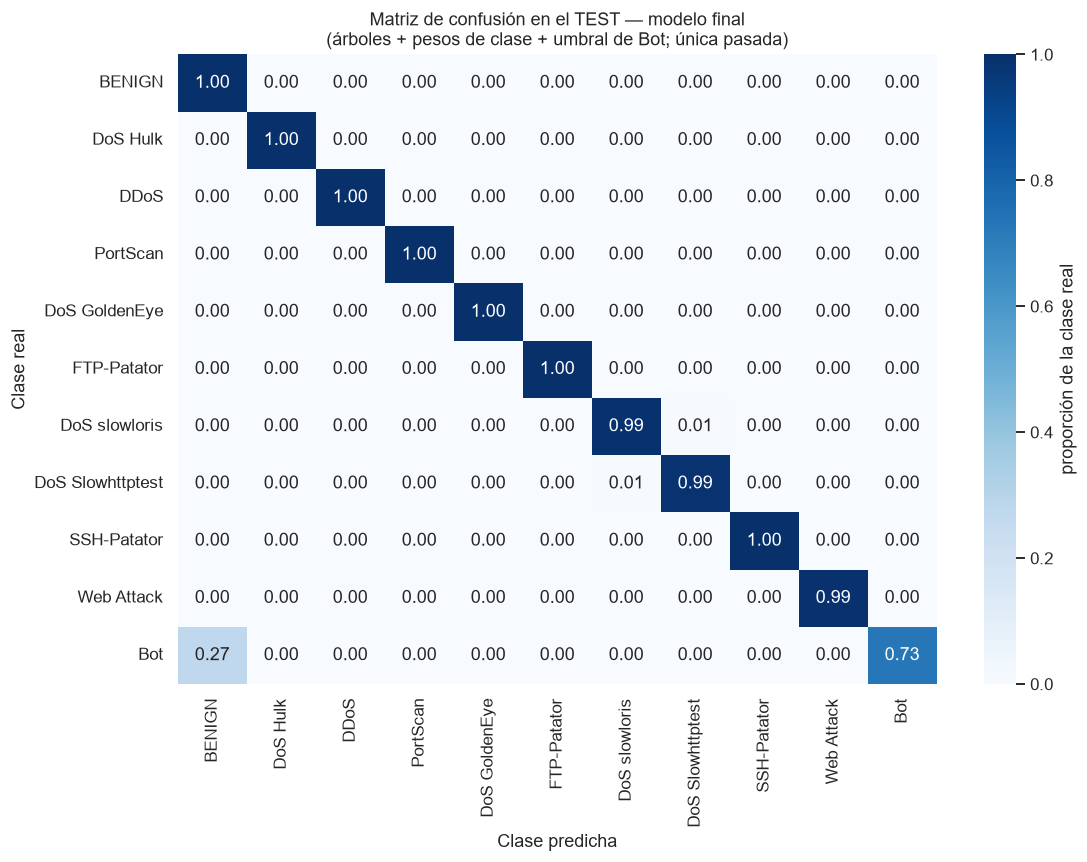

Falsas alarmas sobre BENIGN en test: 489 de 414,468 (0.12%)


In [6]:
conf = pd.read_csv(RUTA_EXPORT / "final_confusion__con_puerto__umbral_bot.csv", index_col=0)
orden = conf.sum(axis=1).sort_values(ascending=False).index
conf = conf.loc[orden, orden]
conf_norm = conf.div(conf.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10.5, 8))
sns.heatmap(conf_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "proporción de la clase real"}, ax=ax)
ax.set_ylabel("Clase real")
ax.set_xlabel("Clase predicha")
ax.set_title("Matriz de confusión en el TEST — modelo final\n"
             "(árboles + pesos de clase + umbral de Bot; única pasada)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "17_confusion_test_final.png", bbox_inches="tight")
plt.show()

benign_mal = int(conf.loc["BENIGN"].drop("BENIGN").sum())
print(f"Falsas alarmas sobre BENIGN en test: {benign_mal:,} de {int(conf.loc['BENIGN'].sum()):,} "
      f"({100 * benign_mal / conf.loc['BENIGN'].sum():.2f}%)")

## 4. Las clases extremadamente raras en el test (cifras ilustrativas)

Heartbleed e Infiltration no entran en el multiclase (11 y 36 casos en total), así que
revisamos si el detector **binario** (Normal vs Ataque, entrenado con todo el conjunto de
entrenamiento) por lo menos las marca como ataque. Con tan pocos casos las cifras son
**ilustrativas y no tienen significancia estadística**, por eso ponemos la n al lado.

In [7]:
print("Detector binario en test: "
      f"recall de ataque = {binario.query('metrica == \'recall_ataque\'')['valor'].iloc[0]:.3f}, "
      f"precisión de ataque = {binario.query('metrica == \'precision_ataque\'')['valor'].iloc[0]:.3f}")
raras_tabla = raras.copy()
raras_tabla["detectadas / n"] = raras_tabla["detectadas"].astype(str) + " de " + raras_tabla["n"].astype(str)
raras_tabla[["clase", "detectadas / n"]]

Detector binario en test: recall de ataque = 1.000, precisión de ataque = 0.994


,clase,detectadas / n
0,Heartbleed,2 de 2
1,Infiltration,3 de 7


Heartbleed: 2 de 2 marcadas como ataque; Infiltration: 3 de 7. Con n = 2 y n = 7 son
resultados coherentes con lo esperado, pero no son evidencia estadística.

## 5. El detector no supervisado sobre el test (única pasada)

In [8]:
tabla_if = if_recall.pivot_table(index="clase", columns="umbral_pct", values="recall").round(3)
tabla_if.columns = [f"umbral {c}%" for c in tabla_if.columns]
tabla_if["n"] = if_recall.groupby("clase")["n"].first()
tabla_if.sort_values("n", ascending=False)

,umbral 0.5%,umbral 1.0%,umbral 2.0%,n
clase,,,,
TODOS LOS ATAQUES,0.011,0.118,0.144,85148
DoS Hulk,0.008,0.244,0.269,34569
DDoS,0.002,0.034,0.061,25603
PortScan,0.000,0.001,0.001,18139
DoS GoldenEye,0.002,0.003,0.005,2057
FTP-Patator,0.000,0.000,0.000,1186
DoS slowloris,0.495,0.517,0.557,1077
DoS Slowhttptest,0.076,0.163,0.765,1046
SSH-Patator,0.000,0.000,0.000,644


In [9]:
tabla_fp = if_fp.pivot_table(index="dia", columns="umbral_pct", values="tasa_falsas_alarmas").round(4)
tabla_fp.columns = [f"umbral {c}%" for c in tabla_fp.columns]
tabla_fp["n_benignos"] = if_fp.groupby("dia")["n_benignos"].first()
tabla_fp

,umbral 0.5%,umbral 1.0%,umbral 2.0%,n_benignos
dia,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0.0914,0.0961,0.1048,19182
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,0.0039,0.0087,0.0186,24252
Friday-WorkingHours-Morning.pcap_ISCX.csv,0.0066,0.0118,0.0216,35573
Monday-WorkingHours.pcap_ISCX.csv,0.0048,0.0098,0.0197,98434
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,0.0032,0.0072,0.0148,48679
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,0.0044,0.0092,0.0177,30452
Tuesday-WorkingHours.pcap_ISCX.csv,0.0048,0.0100,0.0191,79215
Wednesday-workingHours.pcap_ISCX.csv,0.0134,0.0183,0.0274,78681


**El test confirma, casi cifra por cifra, lo que vimos en el entrenamiento:** el
Isolation Forest entrenado solo con el lunes benigno detecta los ataques cuyos flujos
son estructuralmente raros (DoS slowloris 0,52, DoS Hulk 0,24, y las extremadamente
raras Heartbleed con 1 de 2 e Infiltration con 4 de 7 al umbral del 1%, que por la n
tan pequeña son cifras ilustrativas), y sigue **sin ver los ataques camuflados** (fuerza
bruta, PortScan, web y Bot, con recall ≈ 0). Las falsas alarmas siguen el mismo patrón:
~1% la mayoría de los días (el lunes del test, que el modelo nunca vio, da 0,98%, lo que
muestra que el umbral estaba bien calibrado) y **9,6% el viernes en la tarde** (deriva
temporal).

## 6. Cierre

| Resultado final (test, única pasada) | Cifra |
|---|---|
| Modelo final (con puerto + umbral de Bot): macro-F1 | **0,975** (solo ataques: 0,972) |
| Estimación conservadora sin el artefacto del puerto (argmax) | **0,942** (solo ataques: 0,937) |
| Falsas alarmas del modelo final sobre BENIGN | 0,12% |
| Detector binario: recall / precisión de ataque | 1,000 / 0,994 |
| No supervisado: recall global con 1% de falsas alarmas | 11,8% (fuerte solo en flujos estructuralmente raros) |
| ¿La validación cruzada coincide con el test? | Sí: 0,970 frente a 0,967 y 0,950 frente a 0,942 (sin sobreajuste) |

La discusión completa de estos resultados está en el reporte técnico
(`reports/reporte_tecnico_final.pdf`, sección 7.1).